## Combined CSV Workflow

This notebook takes one combined prediction CSV, splits it internally into calibration and test data, exports the `alpha -> qhat_<class>` table, and saves the plots plus metrics into `output/`.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from mcp import MCPTool

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

alpha = 0.1
random_state = 123
prefix = "GravitySpy"

workflow_dir = project_root
output_dir = workflow_dir / "output"
source_csv = project_root / "glitch_confidence_data_1500.csv"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Source CSV : {source_csv}")
print(f"Output dir : {output_dir}")


Source CSV : /Users/srinadb/Desktop/ConformalPrediction/glitch_confidence_data_1500.csv
Output dir : /Users/srinadb/Desktop/ConformalPrediction/output


In [2]:
def save_plot_bundle(mcp, output_dir, prefix=prefix, include_fig2_scatter=True):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    mcp.plot_all(
        output_dir=str(output_dir),
        prefix=prefix,
        show=False,
        include_fig2_scatter=include_fig2_scatter,
    )

    png_plotters = [
        ("coverage", mcp.plot_coverage),
        ("setsize", mcp.plot_set_size),
        ("roc", mcp.plot_roc),
        ("alpha_metrics", mcp.plot_alpha_metrics),
    ]
    if include_fig2_scatter:
        png_plotters.append(("fig2_scatter", mcp.plot_prediction_set_scatter))

    for name, plotter in png_plotters:
        plotter(save_path=output_dir / f"{prefix}_{name}.png", show=False)

Dataset     : 32667 samples, 22 classes
Split       : 16333 calibration | 16334 test
Classes     : ['1080Lines', '1400Ripples', 'Air_Compressor', 'Blip', 'Chirp', 'Extremely_Loud', 'Helix', 'Koi_Fish', 'Light_Modulation', 'Low_Frequency_Burst', 'Low_Frequency_Lines', 'No_Glitch', 'None_of_the_Above', 'Paired_Doves', 'Power_Line', 'Repeating_Blips', 'Scattered_Light', 'Scratchy', 'Tomte', 'Violin_Mode', 'Wandering_Line', 'Whistle']

Running unified alpha sweep …
Computing macro ROC …

Macro AUC = 0.9339 | MCP AUC ≈ 0.9293

-----------------------------------------------
  MCP Metrics Summary   alpha = 0.1000
-----------------------------------------------
  Calibration samples : 16333
  Test samples        : 16334
  Classes             : 22
-----------------------------------------------
  Coverage            : 0.9005   (target >= 0.9000)
  Macro F1-score      : 0.4429
  Average set size    : 5.0675
  Singleton rate      : 0.1626
  True positive rate  : 0.9005
  False positive rate : 0.

alpha                 0.100000
n_cal             16333.000000
n_test            16334.000000
n_classes            22.000000
coverage              0.900514
macro_f1              0.442888
avg_set_size          5.067467
singleton_rate        0.162606
fpr                   0.198426
tpr                   0.900514
dtype: float64

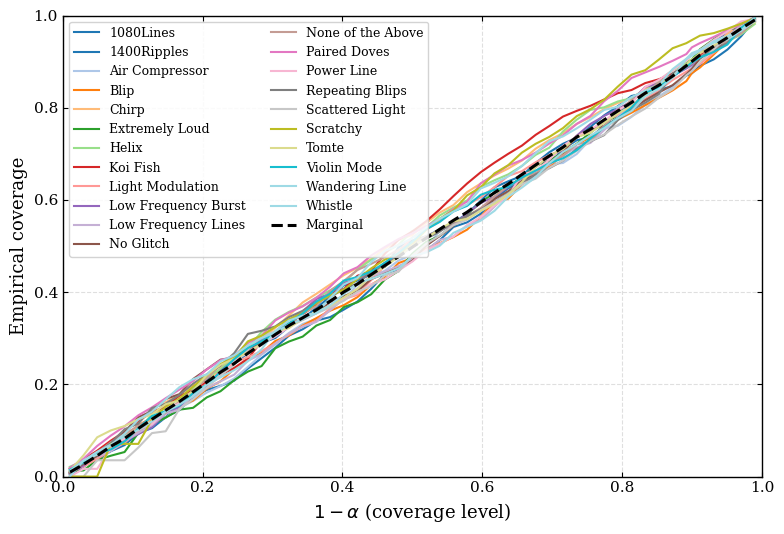

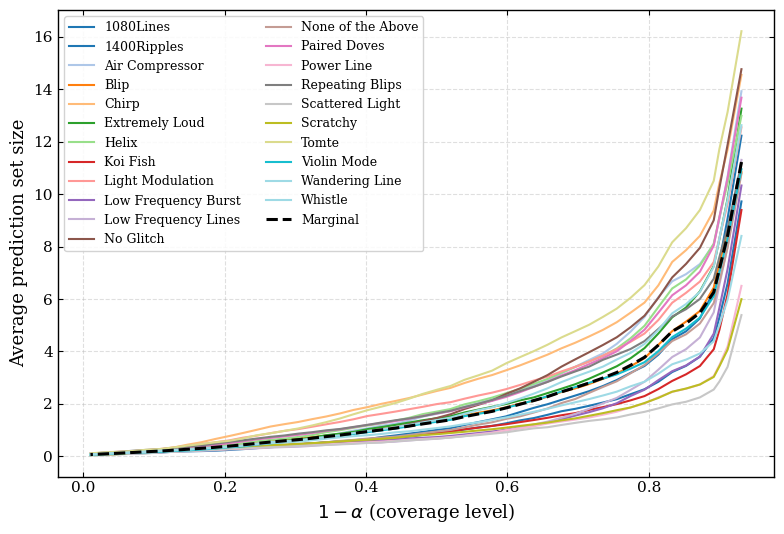

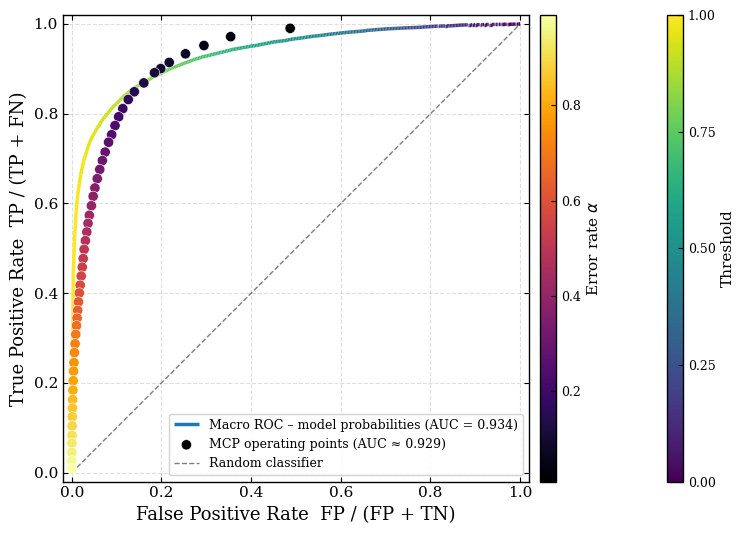

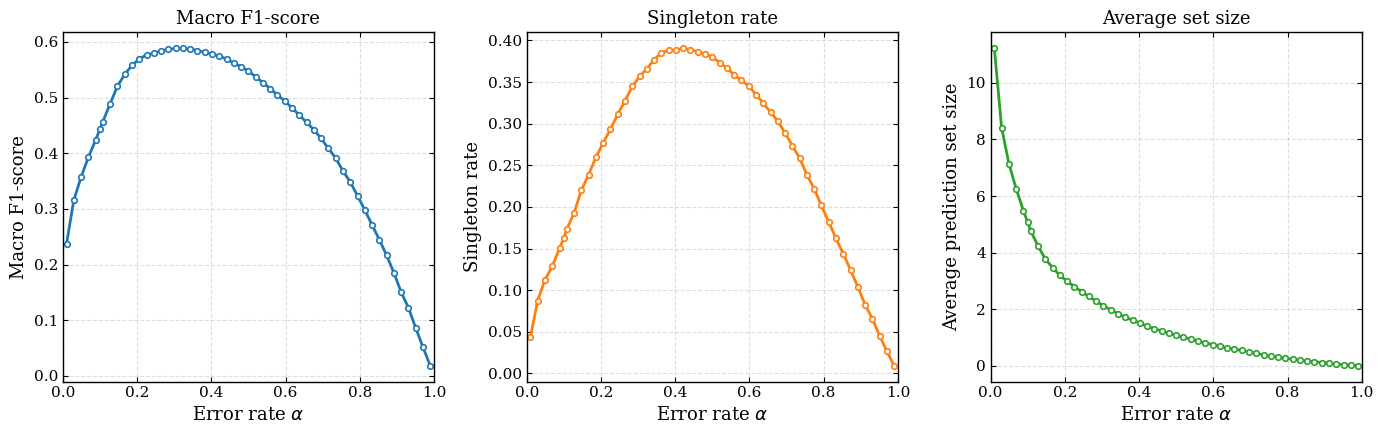

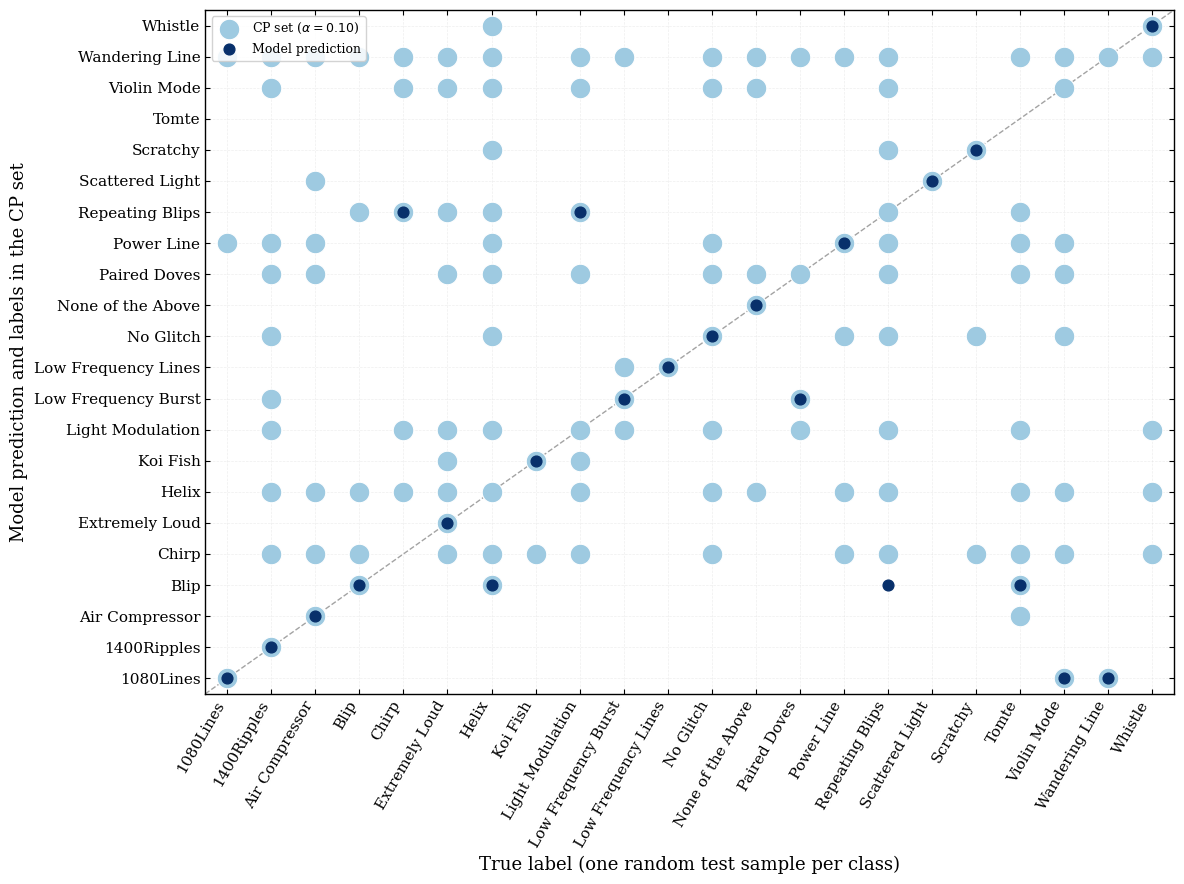

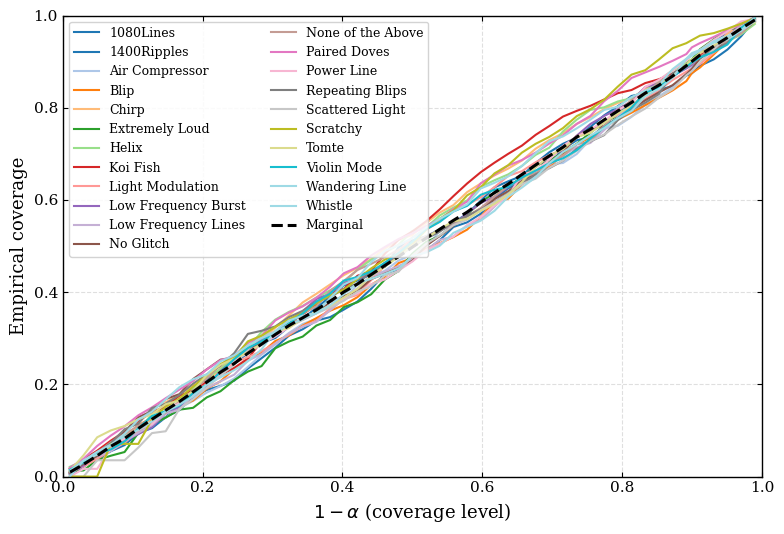

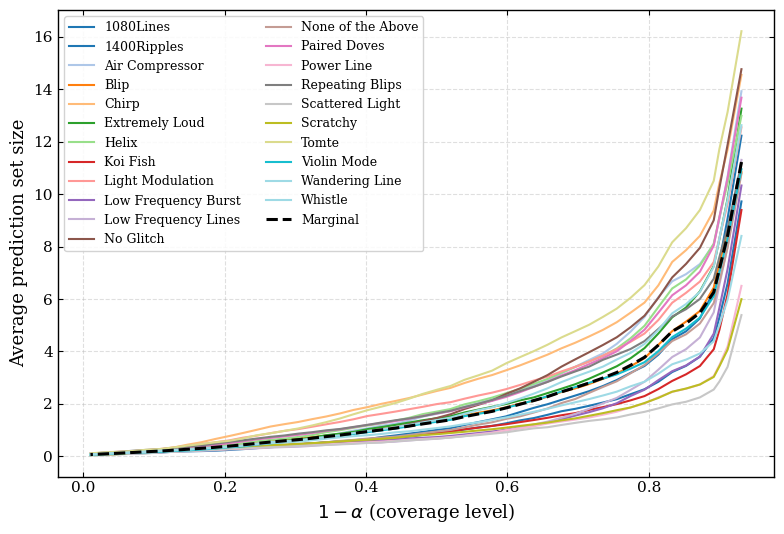

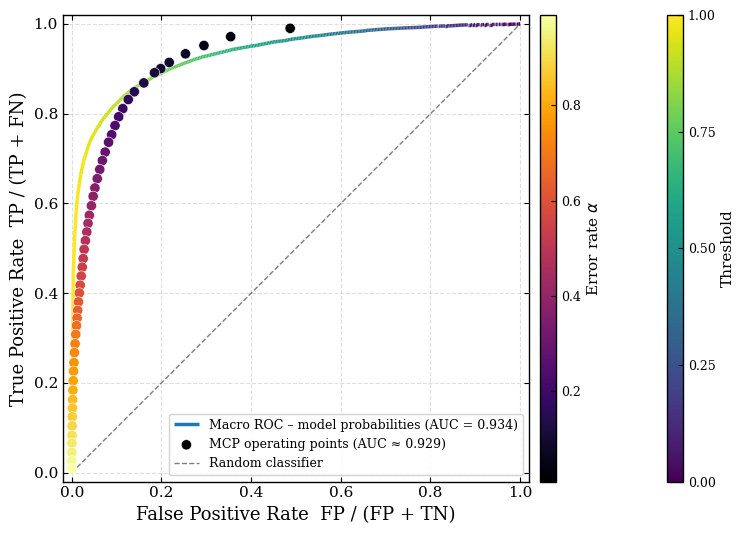

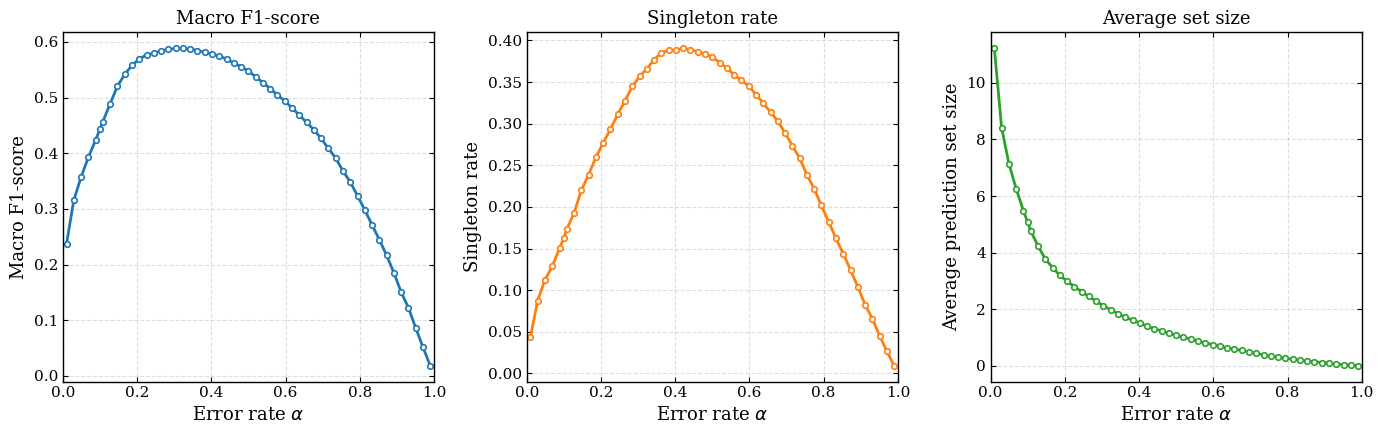

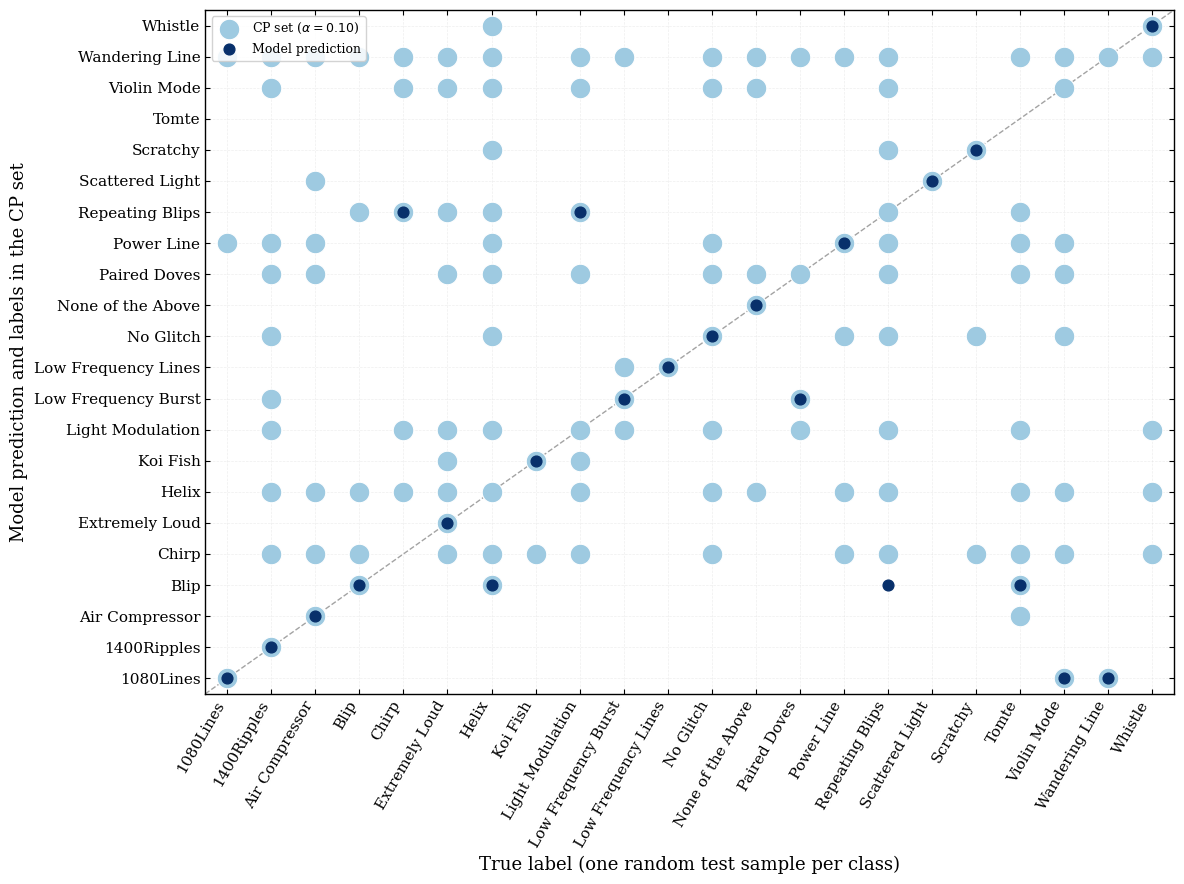

In [3]:
mcp = MCPTool(
    str(source_csv),
    alpha=alpha,
    test_size=0.5,
    random_state=random_state,
).run()

qhat_csv = output_dir / f"{prefix}_qhat.csv"
mcp.export_qhat_csv(qhat_csv)
save_plot_bundle(mcp, output_dir)

summary = mcp.print_metrics()
pd.Series({k: v for k, v in summary.items() if k != "per_label_f1"})


In [4]:
metrics_df = pd.read_csv(output_dir / f"{prefix}_metrics.csv")
metrics_df.head()

,alpha,coverage,macro_f1,avg_set_size,singleton_rate,tpr,fpr,coverage_1080Lines,coverage_1400Ripples,coverage_Air_Compressor,...,setsize_None_of_the_Above,setsize_Paired_Doves,setsize_Power_Line,setsize_Repeating_Blips,setsize_Scattered_Light,setsize_Scratchy,setsize_Tomte,setsize_Violin_Mode,setsize_Wandering_Line,setsize_Whistle
0,0.0100,0.990327,0.237052,11.218807,0.043835,0.990327,0.487070,0.991228,0.985564,0.986092,...,10.780585,13.673307,6.500000,11.189189,5.387942,5.993179,16.207037,10.946381,12.625000,8.403718
1,0.0296,0.971715,0.315491,8.413555,0.087547,0.971715,0.354373,0.954887,0.973753,0.965229,...,7.962766,10.614874,4.192506,8.694595,3.415465,4.069577,13.129905,8.323056,9.779514,5.977424
2,0.0492,0.952002,0.356902,7.142831,0.112342,0.952002,0.294801,0.926065,0.961942,0.955494,...,6.662234,9.124834,3.481912,7.600000,2.855832,3.435198,11.721245,7.009383,8.319444,5.003984
3,0.0688,0.933513,0.392434,6.259030,0.128811,0.933513,0.253596,0.904762,0.947507,0.931850,...,5.845745,8.037185,3.062016,6.772973,2.550459,3.030014,10.504736,6.112601,7.225694,4.391766
4,0.0884,0.914350,0.423576,5.478083,0.150116,0.914350,0.217321,0.890977,0.917323,0.909597,...,5.067819,7.037185,2.740310,6.002703,2.250328,2.742156,9.391069,5.292225,6.270833,3.924303


In [5]:
mcp.predict_one(index=918)

True label       : Chirp
ML prediction    : Repeating_Blips
CP prediction set (alpha=0.1): ['Chirp', 'Helix', 'Light_Modulation', 'Paired_Doves', 'Repeating_Blips', 'Violin_Mode', 'Wandering_Line']


['Chirp',
 'Helix',
 'Light_Modulation',
 'Paired_Doves',
 'Repeating_Blips',
 'Violin_Mode',
 'Wandering_Line']